In [6]:
from scipy.special import softmax
from constants.dcm import get_dcm_theta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
theta = get_dcm_theta(power_rate=6.6)

In [8]:
prices = np.arange(100, 300, 50) / 6.6
grid = [(z_sch, z_reg) for z_sch in prices for z_reg in prices if z_sch <= z_reg]

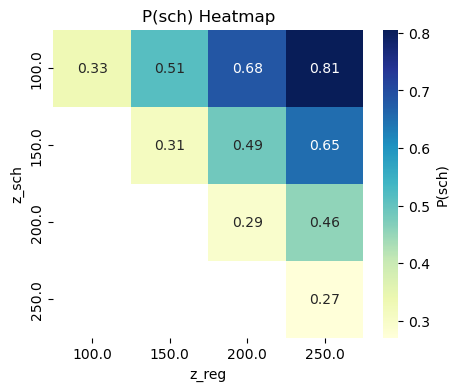

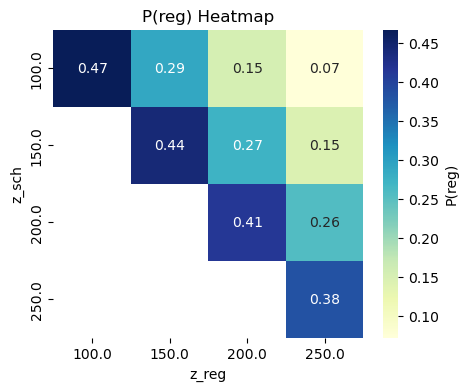

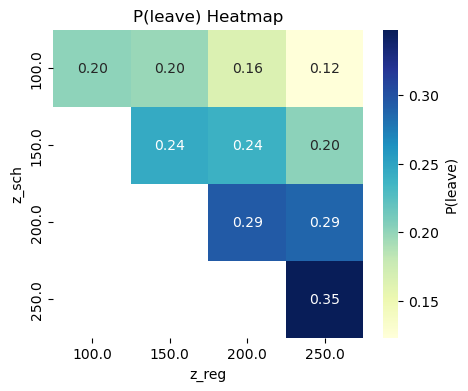

In [9]:
for i, prob in zip([0, 1, 2], ['P(sch)', 'P(reg)', 'P(leave)']):
    data = []
    for z_sch, z_reg in grid:
        zk = [z_sch, z_reg, 1, 1]
        vk = softmax(theta @ zk).reshape(3, 1)
        data.append([z_sch * 6.6, z_reg * 6.6, vk[i][0]])

    # Create a DataFrame with the correct column names
    df = pd.DataFrame(data, columns=["z_sch", "z_reg", prob])

    # Pivot the data correctly
    pivot_table = df.pivot(index="z_sch", columns="z_reg", values=prob)

    # Plotting the heatmap
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        pivot_table,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        cbar_kws={"label": prob},
    )
    plt.title(f"{prob} Heatmap")
    plt.xlabel("z_reg")
    plt.ylabel("z_sch")
    plt.show()

In [10]:
pivot_table

z_reg,100.0,150.0,200.0,250.0
z_sch,,,,
100.0,0.201312,0.197027,0.164985,0.122898
150.0,NaN,0.244510,0.239581,0.202362
200.0,NaN,NaN,0.293569,0.288028
250.0,NaN,NaN,NaN,0.347939


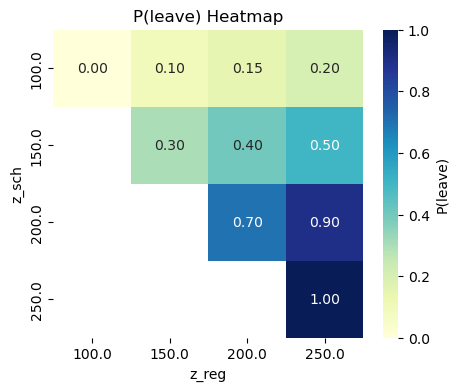

In [15]:
df['P(leave) desired'] = [0, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9, 1]

# Pivot the data correctly
pivot_table = df.pivot(index="z_sch", columns="z_reg", values='P(leave) desired')

# Plotting the heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={"label": prob},
)
plt.title(f"{prob} Heatmap")
plt.xlabel("z_reg")
plt.ylabel("z_sch")
plt.show()